# Exploratory Data Analysis — Tech Triathlon 2026 Datathon
**Team BigBug**

This notebook explores all datasets to understand the data before building models.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Data paths
BASE = Path('..')
GENERAL = BASE / 'data' / 'raw' / 'General Data'
TRAIN = BASE / 'data' / 'raw' / 'Training Data'
TEST = BASE / 'data' / 'raw' / 'Test Data'
TEMPLATES = BASE / 'data' / 'raw' / 'Submission Templates'

print('Setup complete.')

Setup complete.


---
## 1. General Data — Reference Tables
### 1.1 Outlets

In [2]:
outlets = pd.read_csv(GENERAL / 'outlets.csv')
print(f'Shape: {outlets.shape}')
print(f'\nColumns: {list(outlets.columns)}')
print(f'\nNull counts:\n{outlets.isnull().sum()}')
outlets.head()

Shape: (120, 9)

Columns: ['outlet_id', 'brand', 'district', 'depot', 'dock_type', 'parking_constraint', 'mall_window', 'window_open_time', 'window_close_time']

Null counts:
outlet_id               0
brand                   0
district                0
depot                   0
dock_type               0
parking_constraint      0
mall_window           108
window_open_time        0
window_close_time       0
dtype: int64


,outlet_id,brand,district,depot,dock_type,parking_constraint,mall_window,window_open_time,window_close_time
0,OUT001,Fresh,Colombo,Peliyagoda,street,van_only,NaN,05:00,07:30
1,OUT002,Fresh,Colombo,Peliyagoda,street,van_only,NaN,05:30,08:00
2,OUT003,Fresh,Colombo,Peliyagoda,street,van_only,NaN,05:00,07:30
3,OUT004,Fresh,Colombo,Peliyagoda,street,normal,NaN,05:30,08:00
4,OUT005,Fresh,Colombo,Peliyagoda,rear_dock,normal,NaN,04:00,07:45


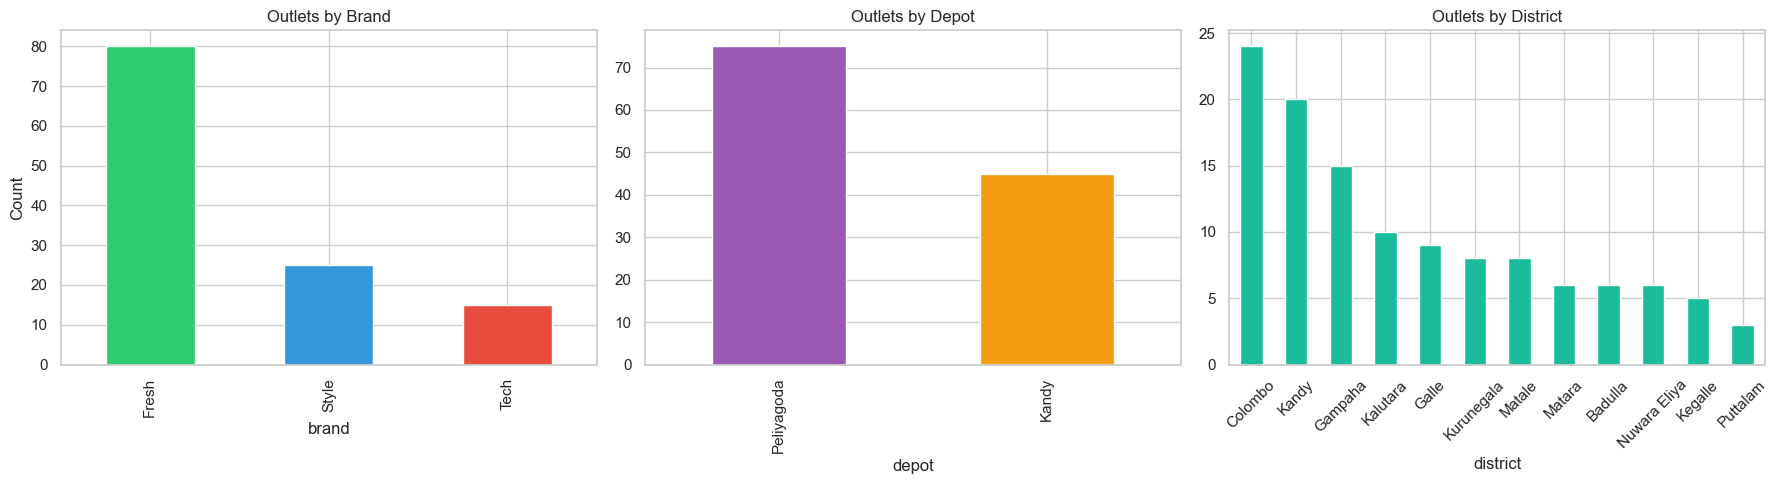

In [3]:
# Outlet distribution by brand, depot, district
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

outlets['brand'].value_counts().plot.bar(ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Outlets by Brand')
axes[0].set_ylabel('Count')

outlets['depot'].value_counts().plot.bar(ax=axes[1], color=['#9b59b6', '#f39c12'])
axes[1].set_title('Outlets by Depot')

outlets['district'].value_counts().plot.bar(ax=axes[2], color='#1abc9c')
axes[2].set_title('Outlets by District')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

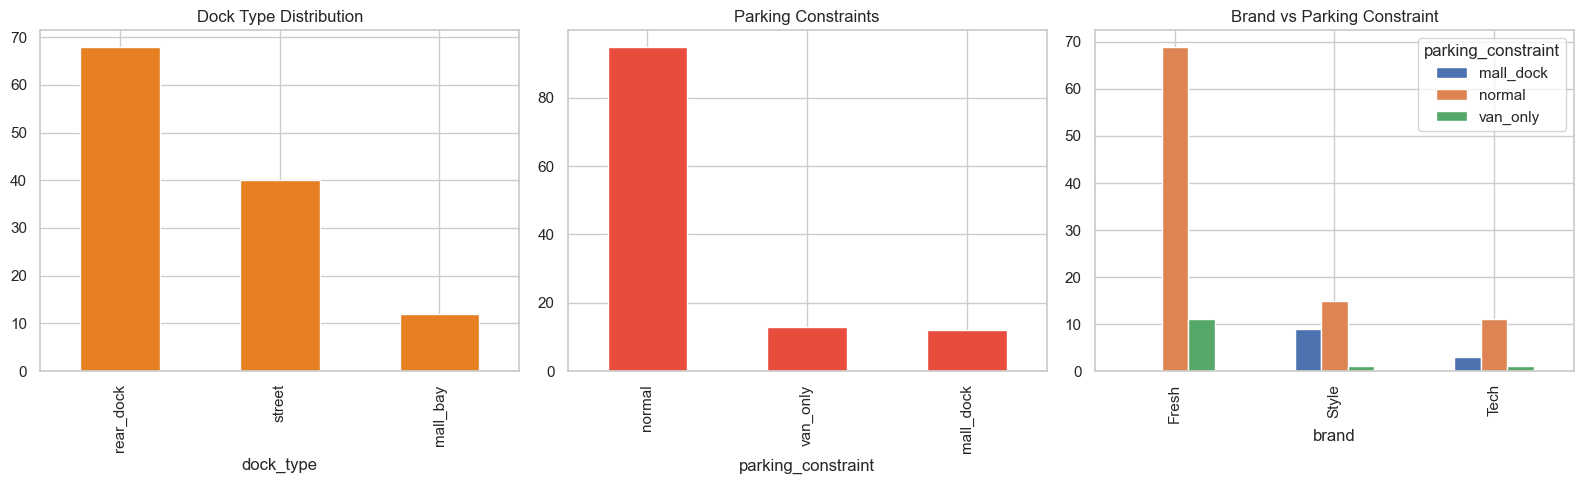

In [4]:
# Outlet access constraints and dock types
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

outlets['dock_type'].value_counts().plot.bar(ax=axes[0], color='#e67e22')
axes[0].set_title('Dock Type Distribution')

outlets['parking_constraint'].value_counts().plot.bar(ax=axes[1], color='#e74c3c')
axes[1].set_title('Parking Constraints')

# Cross-tab: brand vs parking constraint
pd.crosstab(outlets['brand'], outlets['parking_constraint']).plot.bar(ax=axes[2])
axes[2].set_title('Brand vs Parking Constraint')

plt.tight_layout()
plt.show()

In [5]:
# Delivery windows
print('Unique window_open_time values:', outlets['window_open_time'].unique())
print('Unique window_close_time values:', outlets['window_close_time'].unique())
print(f"\nMall outlets: {outlets['mall_window'].notna().sum()}")
print(f"Van-only outlets: {(outlets['parking_constraint'] == 'van_only').sum()}")

# Cross-tab: brand vs depot
print('\nBrand x Depot:')
display(pd.crosstab(outlets['brand'], outlets['depot'], margins=True))

# Cross-tab: brand vs dock_type
print('\nBrand x Dock Type:')
display(pd.crosstab(outlets['brand'], outlets['dock_type'], margins=True))

Unique window_open_time values: ['05:00' '05:30' '04:00' '03:00' '09:00' '10:30' '10:00']
Unique window_close_time values: ['07:30' '08:00' '07:45' '11:00' '12:30' '17:00' '12:00']

Mall outlets: 12
Van-only outlets: 13

Brand x Depot:


depot,Kandy,Peliyagoda,All
brand,,,
Fresh,31,49,80
Style,9,16,25
Tech,5,10,15
All,45,75,120



Brand x Dock Type:


dock_type,mall_bay,rear_dock,street,All
brand,,,,
Fresh,0,55,25,80
Style,9,6,10,25
Tech,3,7,5,15
All,12,68,40,120


### 1.2 Vehicles

In [6]:
vehicles = pd.read_csv(GENERAL / 'vehicles.csv')
print(f'Shape: {vehicles.shape}')
print(f'\nColumns: {list(vehicles.columns)}')
print(f'\nNull counts:\n{vehicles.isnull().sum()}')
vehicles.head()

Shape: (60, 9)

Columns: ['vehicle_id', 'type', 'temp', 'weight_cap_kg', 'volume_cap_m3', 'fuel_type', 'km_per_l', 'weekly_fuel_quota_l', 'depot']

Null counts:
vehicle_id             0
type                   0
temp                   0
weight_cap_kg          0
volume_cap_m3          0
fuel_type              0
km_per_l               0
weekly_fuel_quota_l    0
depot                  0
dtype: int64


,vehicle_id,type,temp,weight_cap_kg,volume_cap_m3,fuel_type,km_per_l,weekly_fuel_quota_l,depot
0,VEH001,truck,reefer,5510,26.4,diesel,4.7,340,Peliyagoda
1,VEH002,truck,reefer,3990,21.1,diesel,6.1,610,Peliyagoda
2,VEH003,truck,reefer,5510,26.4,diesel,4.7,480,Peliyagoda
3,VEH004,truck,reefer,6840,33.4,diesel,4.4,430,Peliyagoda
4,VEH005,truck,reefer,6840,33.4,diesel,4.4,490,Peliyagoda


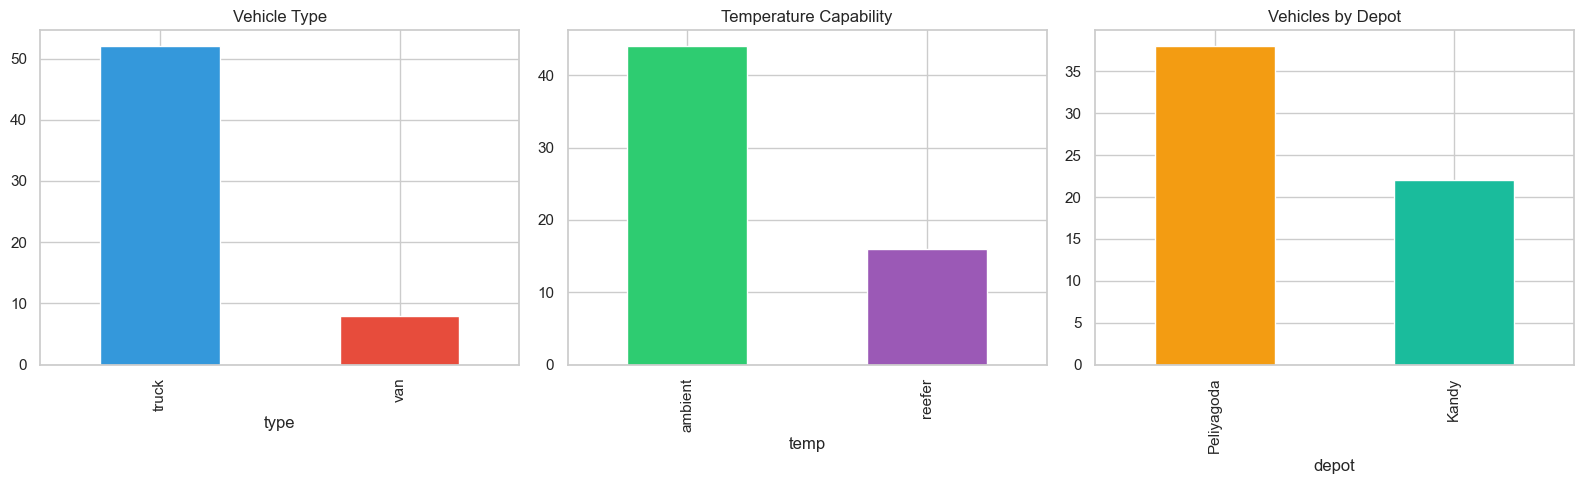

Type x Temp:


temp,ambient,reefer,All
type,,,
truck,40,12,52
van,4,4,8
All,44,16,60



Type x Depot:


depot,Kandy,Peliyagoda,All
type,,,
truck,18,34,52
van,4,4,8
All,22,38,60


In [7]:
# Vehicle composition
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vehicles['type'].value_counts().plot.bar(ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Vehicle Type')

vehicles['temp'].value_counts().plot.bar(ax=axes[1], color=['#2ecc71', '#9b59b6'])
axes[1].set_title('Temperature Capability')

vehicles['depot'].value_counts().plot.bar(ax=axes[2], color=['#f39c12', '#1abc9c'])
axes[2].set_title('Vehicles by Depot')

plt.tight_layout()
plt.show()

# Cross-tab: type vs temp vs depot
print('Type x Temp:')
display(pd.crosstab(vehicles['type'], vehicles['temp'], margins=True))
print('\nType x Depot:')
display(pd.crosstab(vehicles['type'], vehicles['depot'], margins=True))

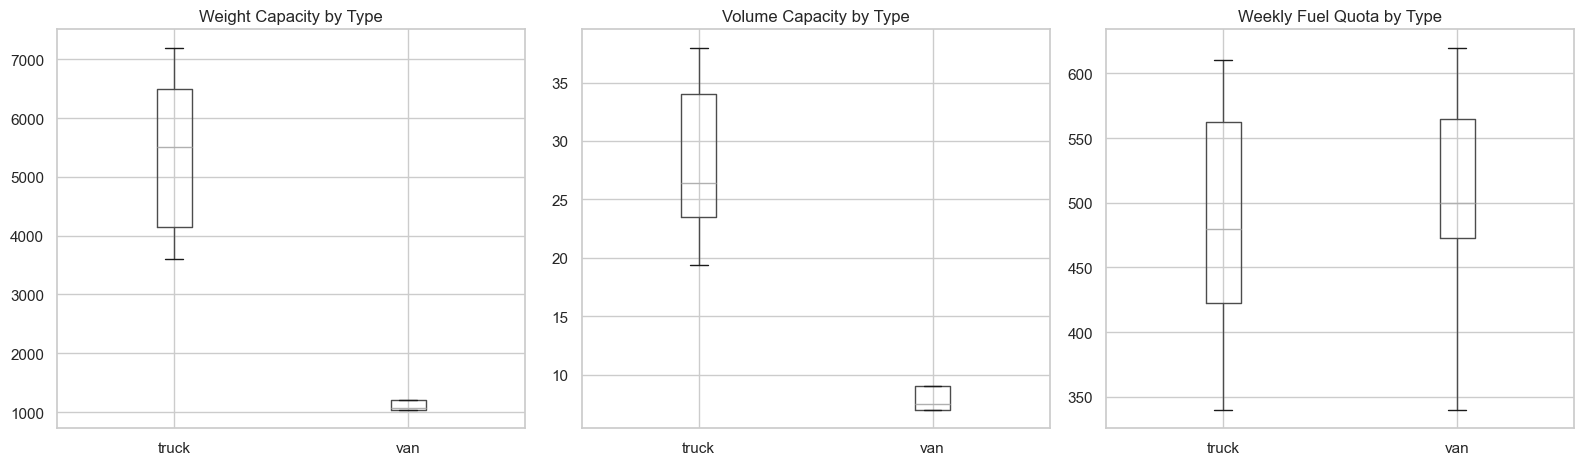


Capacity summary by type:


type                             truck          van
weight_cap_kg       count    52.000000     8.000000
                    mean   5333.269231  1107.500000
                    std    1358.710059    79.237437
                    min    3610.000000  1040.000000
                    25%    4147.500000  1040.000000
                    50%    5510.000000  1070.000000
                    75%    6500.000000  1200.000000
                    max    7200.000000  1200.000000
volume_cap_m3       count    52.000000     8.000000
                    mean     28.375000     7.875000
                    std       6.201134     0.991031
                    min      19.400000     7.000000
                    25%      23.500000     7.000000
                    50%      26.400000     7.500000
                    75%      34.000000     9.000000
                    max      38.000000     9.000000
weekly_fuel_quota_l count    52.000000     8.000000
                    mean    484.807692   506.250000
                    std      88.528059    91.016090
                    min     340.000000   340.000000
                    25%     422.500000   472.500000
                    50%     480.000000   500.000000
                    75%     562.500000   565.000000
                    max     610.000000   620.000000
km_per_l            count    52.000000     8.000000
                    mean      5.869231    10.637500
                    std       0.984495     0.427409
                    min       4.400000    10.300000
                    25%       4.900000    10.300000
                    50%       5.600000    10.550000
                    75%       6.800000    10.800000
                    max       7.100000    11.500000

In [8]:
# Vehicle capacity distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vehicles.boxplot(column='weight_cap_kg', by='type', ax=axes[0])
axes[0].set_title('Weight Capacity by Type')
axes[0].set_xlabel('')

vehicles.boxplot(column='volume_cap_m3', by='type', ax=axes[1])
axes[1].set_title('Volume Capacity by Type')
axes[1].set_xlabel('')

vehicles.boxplot(column='weekly_fuel_quota_l', by='type', ax=axes[2])
axes[2].set_title('Weekly Fuel Quota by Type')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('\nCapacity summary by type:')
display(vehicles.groupby('type')[['weight_cap_kg', 'volume_cap_m3', 'weekly_fuel_quota_l', 'km_per_l']].describe().T)

### 1.3 Calendar

In [9]:
calendar_df = pd.read_csv(GENERAL / 'calendar.csv', parse_dates=['date'])
print(f'Shape: {calendar_df.shape}')
print(f'\nDate range: {calendar_df["date"].min()} to {calendar_df["date"].max()}')
print(f'\nColumns: {list(calendar_df.columns)}')
calendar_df.head(10)

Shape: (910, 12)



Date range: 2024-01-01 00:00:00 to 2026-06-28 00:00:00

Columns: ['date', 'dow', 'dow_name', 'is_weekend', 'iso_year', 'iso_week', 'is_payday', 'festival', 'festival_ramp', 'is_holiday', 'monsoon', 'is_operating']


,date,dow,dow_name,is_weekend,iso_year,iso_week,is_payday,festival,festival_ramp,is_holiday,monsoon,is_operating
0,2024-01-01,0,Mon,0,2024,1,0,NaN,0.0,0,0,1
1,2024-01-02,1,Tue,0,2024,1,0,NaN,0.0,0,0,1
2,2024-01-03,2,Wed,0,2024,1,0,NaN,0.0,0,0,1
3,2024-01-04,3,Thu,0,2024,1,0,NaN,0.0,0,0,1
4,2024-01-05,4,Fri,0,2024,1,0,NaN,0.0,0,0,1
5,2024-01-06,5,Sat,0,2024,1,0,NaN,0.1,0,0,1
6,2024-01-07,6,Sun,1,2024,1,0,NaN,0.2,0,0,0
7,2024-01-08,0,Mon,0,2024,2,0,NaN,0.3,0,0,1
8,2024-01-09,1,Tue,0,2024,2,0,NaN,0.4,0,0,1
9,2024-01-10,2,Wed,0,2024,2,0,NaN,0.5,0,0,1


In [10]:
# Calendar overview
print(f'Total days: {len(calendar_df)}')
print(f'Operating days: {calendar_df["is_operating"].sum()}')
print(f'Non-operating days: {(~calendar_df["is_operating"].astype(bool)).sum()}')
print(f'Paydays: {calendar_df["is_payday"].sum()}')
print(f'Holidays: {calendar_df["is_holiday"].sum()}')
print(f'Monsoon days: {calendar_df["monsoon"].sum()}')
print(f'\nFestivals:')
display(calendar_df[calendar_df['festival'].notna()][['date', 'festival', 'festival_ramp', 'is_holiday']].reset_index(drop=True))

print(f'\nISO weeks range: {calendar_df["iso_week"].min()} to {calendar_df["iso_week"].max()}')
print(f'ISO years: {calendar_df["iso_year"].unique()}')

Total days: 910
Operating days: 770
Non-operating days: 140
Paydays: 59
Holidays: 23
Monsoon days: 486

Festivals:


,date,festival,festival_ramp,is_holiday
0,2024-01-15,thai_pongal,1.0,1
1,2024-04-13,new_year,1.0,1
2,2024-05-23,vesak,1.0,1
3,2024-06-21,poson,1.0,1
4,2024-08-19,esala,1.0,1
5,2024-10-31,deepavali,1.0,1
6,2024-12-25,christmas,1.0,1
7,2025-01-14,thai_pongal,1.0,1
8,2025-04-14,new_year,1.0,1
9,2025-05-12,vesak,1.0,1



ISO weeks range: 1 to 52
ISO years: [2024 2025 2026]


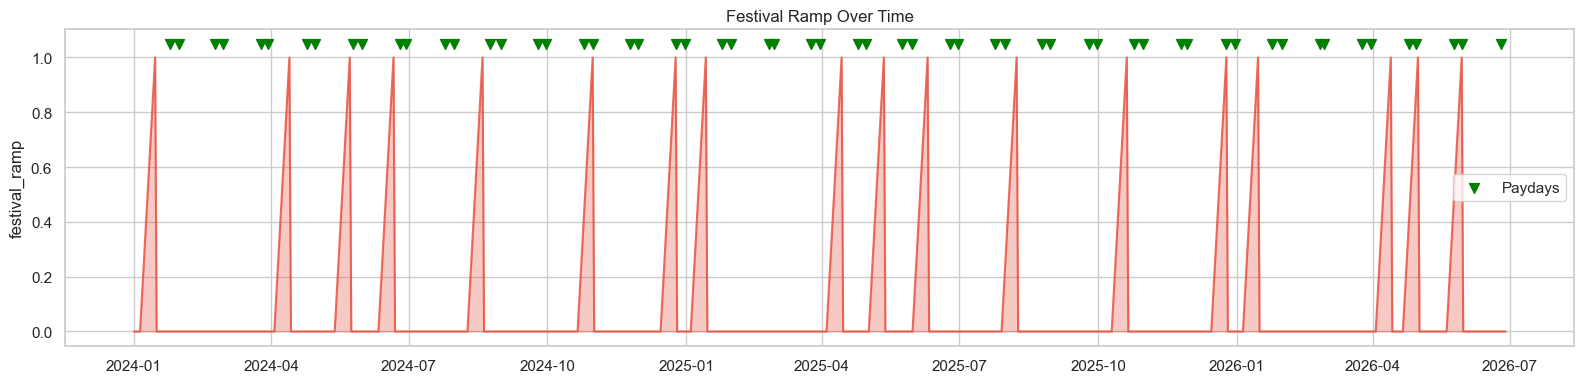

In [11]:
# Festival ramp visualization
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(calendar_df['date'], calendar_df['festival_ramp'], color='#e74c3c', alpha=0.8)
ax.fill_between(calendar_df['date'], calendar_df['festival_ramp'], alpha=0.3, color='#e74c3c')
ax.set_title('Festival Ramp Over Time')
ax.set_ylabel('festival_ramp')

# Mark paydays
paydays = calendar_df[calendar_df['is_payday'] == 1]
ax.scatter(paydays['date'], [1.05] * len(paydays), marker='v', color='green', s=50, label='Paydays', zorder=5)
ax.legend()
plt.tight_layout()
plt.show()

### 1.4 District Travel

In [12]:
district_travel = pd.read_csv(GENERAL / 'district_travel.csv')
print(f'Shape: {district_travel.shape}')
display(district_travel)

print(f'\nDistricts: {district_travel["district"].nunique()} unique')
print(f'Road classes: {district_travel["road_class"].unique()}')

Shape: (12, 8)


,district,depot,road_class,free_flow_kmh,depot_to_district_km,depot_to_district_freeflow_min,inter_stop_km,inter_stop_freeflow_min
0,Colombo,Peliyagoda,urban,30.0,12,24,4.0,8
1,Gampaha,Peliyagoda,suburban,45.0,28,37,7.0,9
2,Kalutara,Peliyagoda,suburban,45.0,48,64,9.0,12
3,Galle,Peliyagoda,highway,70.0,120,103,10.0,9
4,Matara,Peliyagoda,highway,70.0,160,137,12.0,10
5,Kurunegala,Peliyagoda,suburban,45.0,95,127,14.0,19
6,Puttalam,Peliyagoda,suburban,45.0,130,173,18.0,24
7,Kandy,Kandy,urban,30.0,8,16,3.0,6
8,Matale,Kandy,suburban,45.0,26,35,8.0,11
9,Nuwara Eliya,Kandy,hill,42.0,78,111,14.0,20



Districts: 12 unique
Road classes: ['urban' 'suburban' 'highway' 'hill']


### 1.5 Service Allowance

In [13]:
service_allowance = pd.read_csv(GENERAL / 'service_allowance.csv')
print(f'Shape: {service_allowance.shape}')
display(service_allowance)

# Pivot for readability
print('\nService allowance (minutes) — Brand x Dock Type:')
display(service_allowance.pivot(index='brand', columns='dock_type', values='service_allowance_min'))

Shape: (9, 3)


,brand,dock_type,service_allowance_min
0,Fresh,rear_dock,15
1,Fresh,street,16
2,Fresh,mall_bay,18
3,Style,rear_dock,38
4,Style,street,46
5,Style,mall_bay,59
6,Tech,rear_dock,43
7,Tech,street,55
8,Tech,mall_bay,55



Service allowance (minutes) — Brand x Dock Type:


dock_type,mall_bay,rear_dock,street
brand,,,
Fresh,18,15,16
Style,59,38,46
Tech,55,43,55


### 1.6 Traffic Speed

In [14]:
traffic_speed = pd.read_csv(GENERAL / 'traffic_speed.csv')
print(f'Shape: {traffic_speed.shape}')
print(f'\nColumns: {list(traffic_speed.columns)}')
display(traffic_speed.head(10))
display(traffic_speed.describe())

Shape: (576, 4)

Columns: ['district', 'hour', 'monsoon', 'speed_index']


,district,hour,monsoon,speed_index
0,Colombo,0,0,94
1,Colombo,1,0,94
2,Colombo,2,0,94
3,Colombo,3,0,92
4,Colombo,4,0,89
5,Colombo,5,0,79
6,Colombo,6,0,68
7,Colombo,7,0,47
8,Colombo,8,0,46
9,Colombo,9,0,55


,hour,monsoon,speed_index
count,576.000000,576.000000,576.000000
mean,11.500000,0.500000,75.918403
std,6.928203,0.500435,14.624171
min,0.000000,0.000000,32.000000
25%,5.750000,0.000000,67.000000
50%,11.500000,0.500000,78.000000
75%,17.250000,1.000000,87.000000
max,23.000000,1.000000,100.000000


### 1.7 Road Conditions

In [15]:
road_conditions = pd.read_csv(GENERAL / 'road_conditions.csv')
print(f'Shape: {road_conditions.shape}')
print(f'\nColumns: {list(road_conditions.columns)}')
display(road_conditions.head(10))
display(road_conditions.describe())

# How many disrupted days?
if 'disruption_index' in road_conditions.columns:
    disrupted = road_conditions[road_conditions['disruption_index'] < 100]
    print(f'\nDisrupted records (disruption_index < 100): {len(disrupted)} / {len(road_conditions)}')

Shape: (10920, 3)

Columns: ['district', 'date', 'disruption_index']


,district,date,disruption_index
0,Colombo,2024-01-01,100
1,Colombo,2024-01-02,81
2,Colombo,2024-01-03,100
3,Colombo,2024-01-04,100
4,Colombo,2024-01-05,98
5,Colombo,2024-01-06,100
6,Colombo,2024-01-07,100
7,Colombo,2024-01-08,100
8,Colombo,2024-01-09,100
9,Colombo,2024-01-10,100


,disruption_index
count,10920.000000
mean,92.324542
std,13.173265
min,40.000000
25%,90.000000
50%,99.000000
75%,100.000000
max,100.000000



Disrupted records (disruption_index < 100): 6205 / 10920


---
## 2. Training Data
### 2.1 Deliveries (Training)

In [16]:
deliveries = pd.read_csv(TRAIN / 'deliveries_train.csv')
print(f'Shape: {deliveries.shape}')
print(f'\nColumns: {list(deliveries.columns)}')
print(f'\nDtypes:\n{deliveries.dtypes}')
print(f'\nNull counts:\n{deliveries.isnull().sum()}')
deliveries.head()

Shape: (92307, 20)



Columns: ['delivery_id', 'order_date', 'dispatch_date', 'dispatch_status', 'outlet_id', 'brand', 'district', 'depot', 'temp_requirement', 'order_units', 'order_weight_kg', 'order_volume_m3', 'route_id', 'seq_in_route', 'vehicle_id', 'vehicle_type', 'vehicle_temp', 'planned_arrival_time', 'window_open_time', 'window_close_time']

Dtypes:
delivery_id              object
order_date               object
dispatch_date            object
dispatch_status          object
outlet_id                object
brand                    object
district                 object
depot                    object
temp_requirement         object
order_units               int64
order_weight_kg         float64
order_volume_m3         float64
route_id                 object
seq_in_route            float64
vehicle_id               object
vehicle_type             object
vehicle_temp             object
planned_arrival_time     object
window_open_time         object
window_close_time        object
dtype: object



Null counts:
delivery_id               0
order_date                0
dispatch_date           413
dispatch_status           0
outlet_id                 0
brand                     0
district                  0
depot                     0
temp_requirement          0
order_units               0
order_weight_kg           0
order_volume_m3           0
route_id                413
seq_in_route            413
vehicle_id              413
vehicle_type            413
vehicle_temp            413
planned_arrival_time    413
window_open_time          0
window_close_time         0
dtype: int64


,delivery_id,order_date,dispatch_date,dispatch_status,outlet_id,brand,district,depot,temp_requirement,order_units,order_weight_kg,order_volume_m3,route_id,seq_in_route,vehicle_id,vehicle_type,vehicle_temp,planned_arrival_time,window_open_time,window_close_time
0,ORD0000001,2024-01-01,2024-01-01,attempted,OUT001,Fresh,Colombo,Peliyagoda,ambient,8,71.1,0.402,R000015,0.0,VEH037,van,ambient,05:00,05:00,07:30
1,ORD0000002,2024-01-01,2024-01-01,attempted,OUT002,Fresh,Colombo,Peliyagoda,ambient,15,101.0,0.564,R000015,2.0,VEH037,van,ambient,05:49,05:30,08:00
2,ORD0000003,2024-01-01,2024-01-01,attempted,OUT003,Fresh,Colombo,Peliyagoda,ambient,15,91.2,0.552,R000015,1.0,VEH037,van,ambient,05:25,05:00,07:30
3,ORD0000004,2024-01-01,2024-01-01,attempted,OUT004,Fresh,Colombo,Peliyagoda,ambient,35,207.1,1.206,R000031,1.0,VEH012,truck,ambient,06:21,05:30,08:00
4,ORD0000005,2024-01-01,2024-01-01,attempted,OUT005,Fresh,Colombo,Peliyagoda,ambient,54,437.0,2.028,R000030,3.0,VEH034,truck,ambient,06:02,04:00,07:45


In [17]:
# Basic stats
print(f'Unique delivery_ids: {deliveries["delivery_id"].nunique()}')
print(f'Unique outlets: {deliveries["outlet_id"].nunique()}')
print(f'Unique routes: {deliveries["route_id"].nunique()}')
print(f'Unique vehicles: {deliveries["vehicle_id"].nunique()}')
print(f'\nDate range: {deliveries["order_date"].min()} to {deliveries["order_date"].max()}')

# Dispatch status distribution
print(f'\nDispatch status:')
display(deliveries['dispatch_status'].value_counts())
display(deliveries['dispatch_status'].value_counts(normalize=True).mul(100).round(1))

Unique delivery_ids: 92307
Unique outlets: 120
Unique routes: 25198
Unique vehicles: 44

Date range: 2024-01-01 to 2026-02-14

Dispatch status:


dispatch_status
attempted    90351
deferred      1543
not_run        413
Name: count, dtype: int64

dispatch_status
attempted    97.9
deferred      1.7
not_run       0.4
Name: proportion, dtype: float64

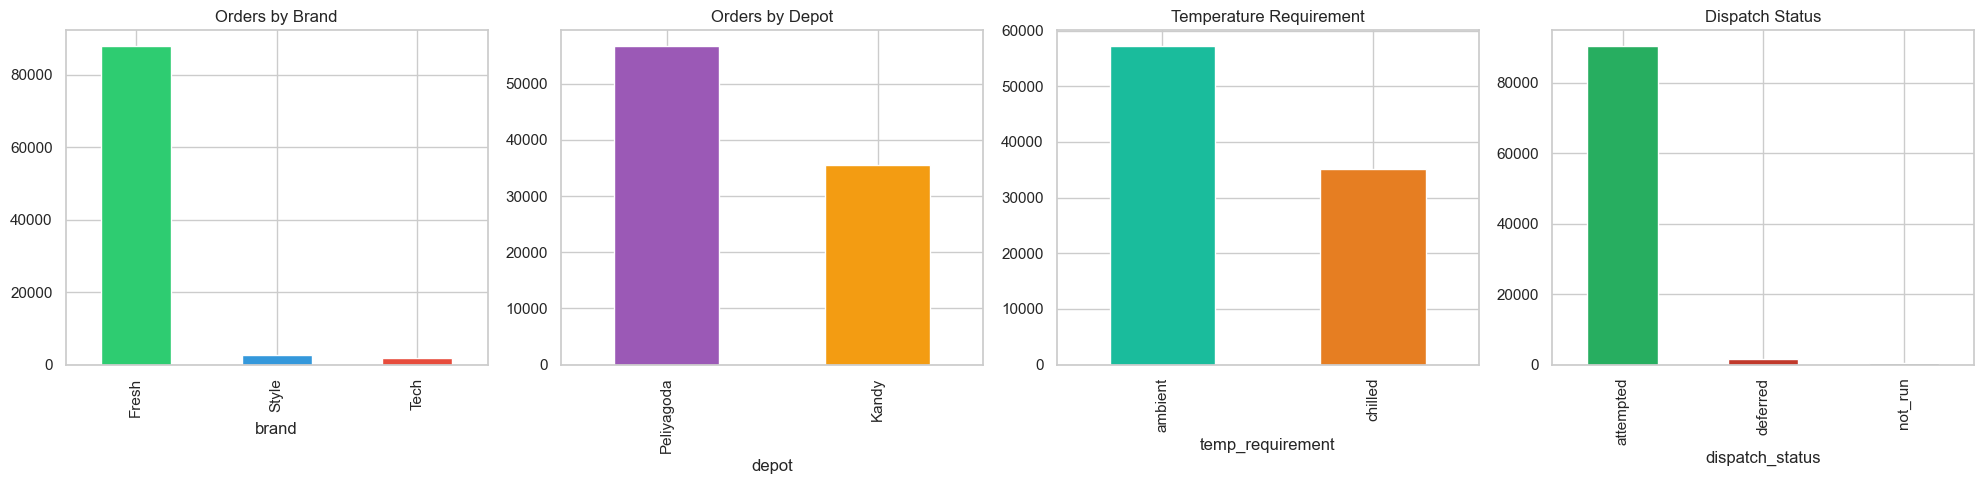

In [18]:
# Distributions by brand, depot, temperature
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

deliveries['brand'].value_counts().plot.bar(ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Orders by Brand')

deliveries['depot'].value_counts().plot.bar(ax=axes[1], color=['#9b59b6', '#f39c12'])
axes[1].set_title('Orders by Depot')

deliveries['temp_requirement'].value_counts().plot.bar(ax=axes[2], color=['#1abc9c', '#e67e22'])
axes[2].set_title('Temperature Requirement')

deliveries['dispatch_status'].value_counts().plot.bar(ax=axes[3], color=['#27ae60', '#c0392b', '#7f8c8d'])
axes[3].set_title('Dispatch Status')

plt.tight_layout()
plt.show()

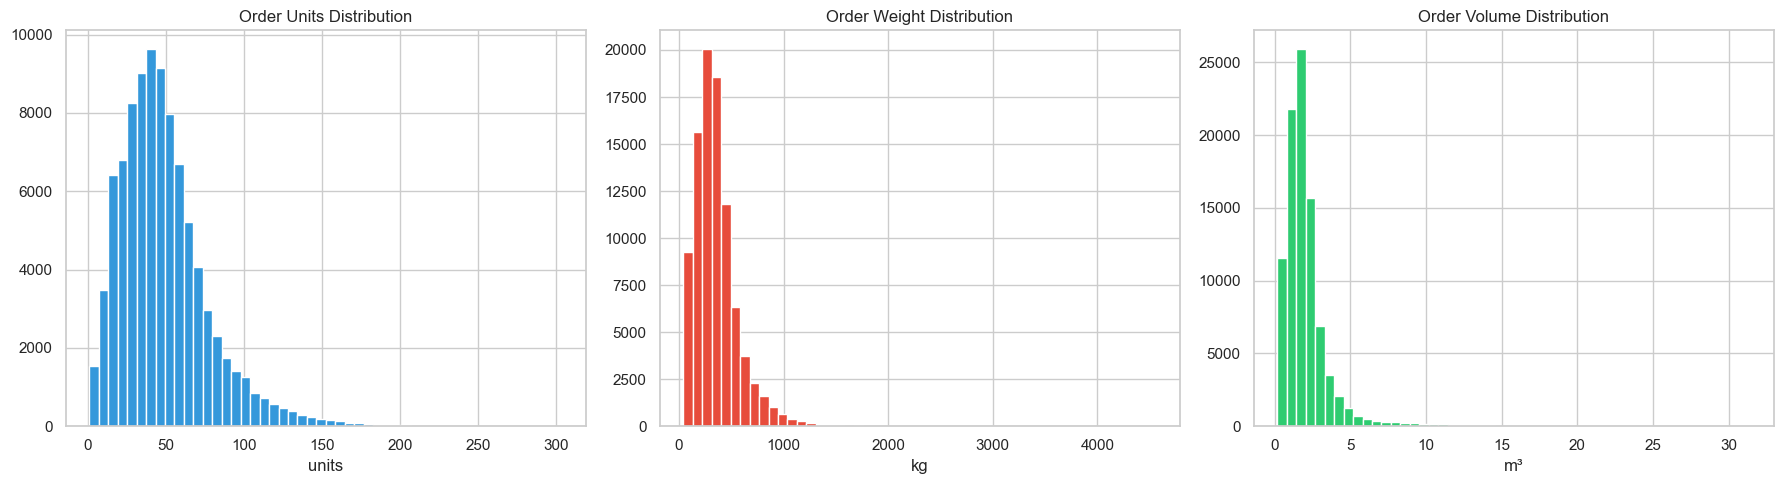

Order size summary by brand:


order_units                                             order_weight_kg  \
            count   mean    std  min   25%   50%   75%    max           count   
brand                                                                           
Fresh     87855.0  49.98  28.42  5.0  30.0  45.0  63.0  304.0         87855.0   
Style      2740.0  38.07  16.44  6.0  27.0  35.0  46.0  136.0          2740.0   
Tech       1712.0   4.68   3.04  1.0   3.0   4.0   6.0   22.0          1712.0   

               ...                  order_volume_m3                          \
         mean  ...      75%     max           count  mean   std   min   25%   
brand          ...                                                            
Fresh  340.32  ...   425.00  2219.8         87855.0  1.84  1.01  0.23  1.14   
Style  558.44  ...   678.15  2063.1          2740.0  8.99  3.68  1.54  6.59   
Tech   992.79  ...  1268.85  4563.2          1712.0  3.31  2.12  0.18  1.89   

                           
        50%    75%    max  
brand                      
Fresh  1.68   2.29  10.83  
Style  8.36  10.93  31.44  
Tech   2.78   4.21  15.34  

[3 rows x 24 columns]

In [19]:
# Order size distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

deliveries['order_units'].hist(bins=50, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Order Units Distribution')
axes[0].set_xlabel('units')

deliveries['order_weight_kg'].hist(bins=50, ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Order Weight Distribution')
axes[1].set_xlabel('kg')

deliveries['order_volume_m3'].hist(bins=50, ax=axes[2], color='#2ecc71', edgecolor='white')
axes[2].set_title('Order Volume Distribution')
axes[2].set_xlabel('m³')

plt.tight_layout()
plt.show()

print('Order size summary by brand:')
display(deliveries.groupby('brand')[['order_units', 'order_weight_kg', 'order_volume_m3']].describe().round(2))

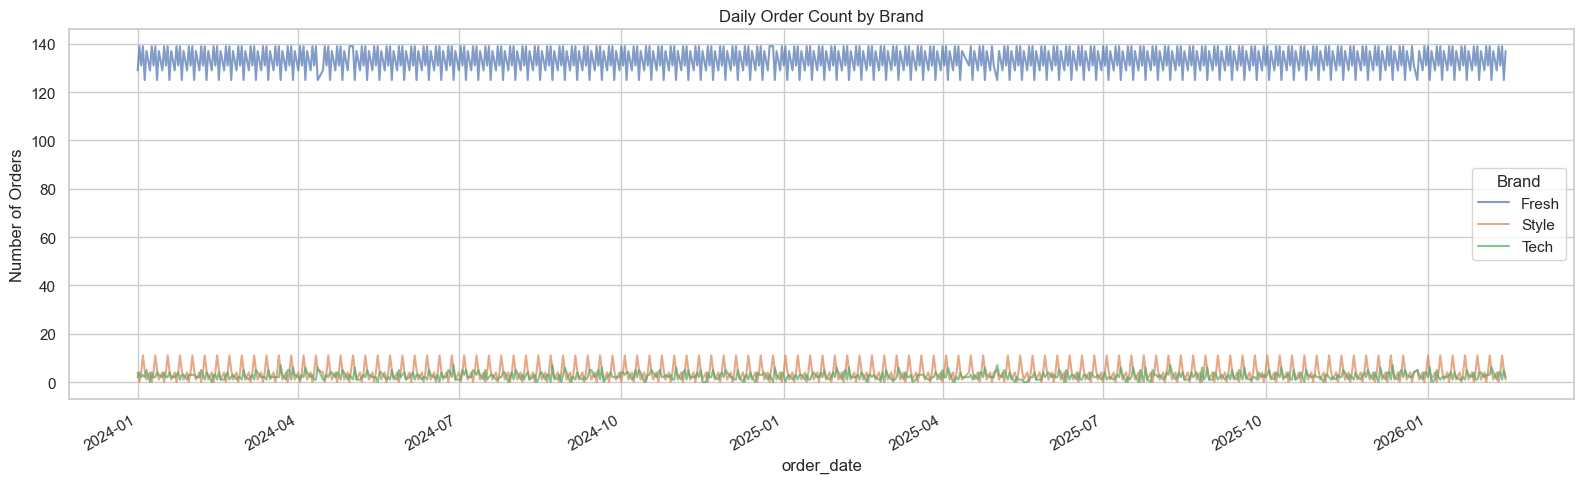

In [20]:
# Temporal patterns — orders per day
deliveries['order_date'] = pd.to_datetime(deliveries['order_date'])
daily_orders = deliveries.groupby(['order_date', 'brand']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
daily_orders.plot(ax=ax, alpha=0.7)
ax.set_title('Daily Order Count by Brand')
ax.set_ylabel('Number of Orders')
ax.legend(title='Brand')
plt.tight_layout()
plt.show()

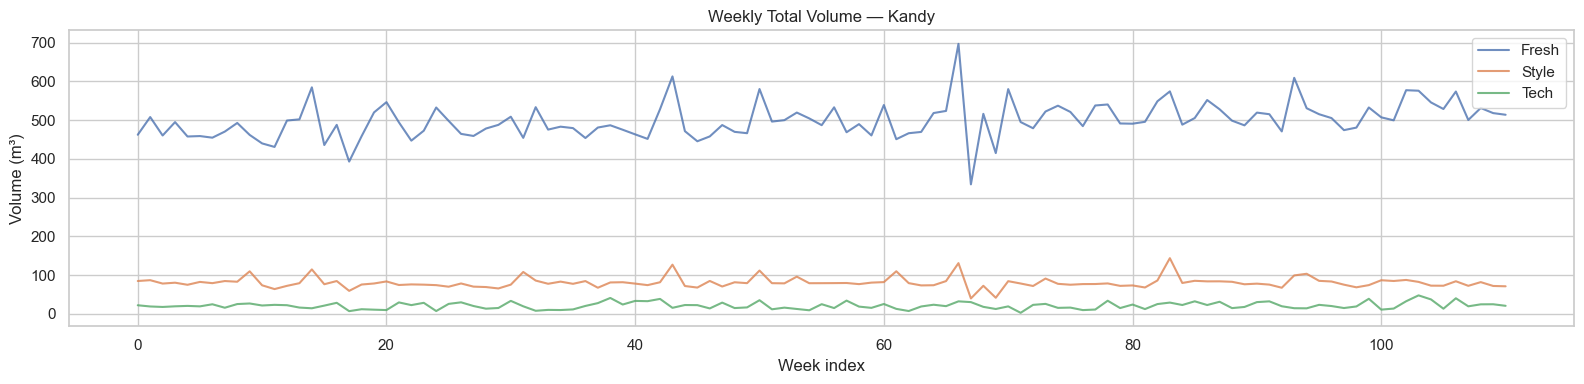

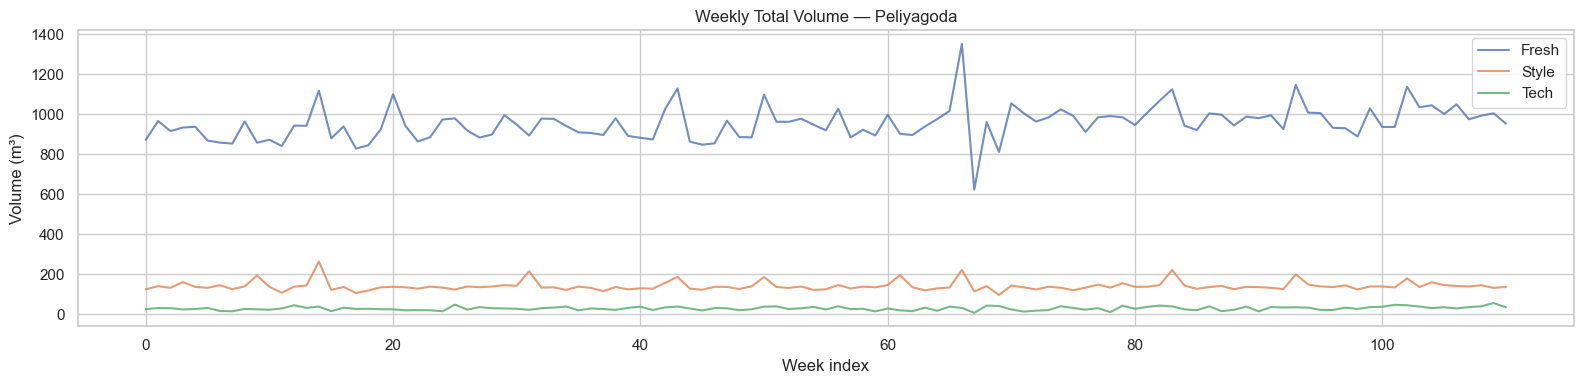

In [21]:
# Weekly volume by depot and brand (preview of Task 2A aggregation)
deliveries_cal = deliveries.merge(
    calendar_df[['date', 'iso_year', 'iso_week']], 
    left_on='order_date', right_on='date', how='left'
)

weekly_vol = deliveries_cal.groupby(['depot', 'brand', 'iso_year', 'iso_week']).agg(
    total_volume=('order_volume_m3', 'sum'),
    order_count=('delivery_id', 'count')
).reset_index()

# Plot weekly volume for each depot
for depot in weekly_vol['depot'].unique():
    depot_data = weekly_vol[weekly_vol['depot'] == depot]
    fig, ax = plt.subplots(figsize=(16, 4))
    for brand in depot_data['brand'].unique():
        brand_data = depot_data[depot_data['brand'] == brand]
        ax.plot(range(len(brand_data)), brand_data['total_volume'], label=brand, alpha=0.8)
    ax.set_title(f'Weekly Total Volume — {depot}')
    ax.set_ylabel('Volume (m³)')
    ax.set_xlabel('Week index')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [22]:
# Chilled vs ambient — only Fresh should have chilled
print('Temperature requirement by brand:')
display(pd.crosstab(deliveries['brand'], deliveries['temp_requirement'], margins=True))

# Verify: only Fresh has chilled
chilled_non_fresh = deliveries[(deliveries['temp_requirement'] == 'chilled') & (deliveries['brand'] != 'Fresh')]
print(f'\nChilled orders for non-Fresh brands: {len(chilled_non_fresh)} (should be 0)')

Temperature requirement by brand:


temp_requirement,ambient,chilled,All
brand,,,
Fresh,52720,35135,87855
Style,2740,0,2740
Tech,1712,0,1712
All,57172,35135,92307



Chilled orders for non-Fresh brands: 0 (should be 0)


In [23]:
# Fresh outlets with dual orders (same outlet, same day)
fresh_orders = deliveries[deliveries['brand'] == 'Fresh']
dual_orders = fresh_orders.groupby(['outlet_id', 'order_date']).size().reset_index(name='order_count')
print(f'Fresh outlet-days with 2+ orders: {(dual_orders["order_count"] >= 2).sum()}')
print(f'Fresh outlet-days with exactly 1 order: {(dual_orders["order_count"] == 1).sum()}')
print(f'Max orders per Fresh outlet per day: {dual_orders["order_count"].max()}')

Fresh outlet-days with 2+ orders: 35135
Fresh outlet-days with exactly 1 order: 17585
Max orders per Fresh outlet per day: 2


### 2.2 Route Legs (Training)

In [24]:
route_legs = pd.read_csv(TRAIN / 'route_legs_train.csv')
print(f'Shape: {route_legs.shape}')
print(f'\nColumns: {list(route_legs.columns)}')
print(f'\nNull counts:\n{route_legs.isnull().sum()}')
route_legs.head()

Shape: (91894, 22)

Columns: ['leg_id', 'date', 'route_id', 'depot', 'vehicle_id', 'vehicle_type', 'vehicle_temp', 'brand', 'district', 'seq', 'from_point', 'to_outlet', 'distance_km', 'planned_depart_time', 'planned_travel_duration_min', 'planned_arrival_time', 'actual_depart_time', 'actual_travel_duration_min', 'arrival_time', 'leave_outlet_time', 'monsoon', 'dow']



Null counts:
leg_id                         0
date                           0
route_id                       0
depot                          0
vehicle_id                     0
vehicle_type                   0
vehicle_temp                   0
brand                          0
district                       0
seq                            0
from_point                     0
to_outlet                      0
distance_km                    0
planned_depart_time            0
planned_travel_duration_min    0
planned_arrival_time           0
actual_depart_time             0
actual_travel_duration_min     0
arrival_time                   0
leave_outlet_time              0
monsoon                        0
dow                            0
dtype: int64

,leg_id,date,route_id,depot,vehicle_id,vehicle_type,vehicle_temp,brand,district,seq,...,distance_km,planned_depart_time,planned_travel_duration_min,planned_arrival_time,actual_depart_time,actual_travel_duration_min,arrival_time,leave_outlet_time,monsoon,dow
0,L0000001,2024-01-01,R000001,Kandy,VEH057,van,reefer,Fresh,Kandy,0,...,8.2,04:24,16,04:40,04:31,17,04:48,05:12,0,0
1,L0000002,2024-01-01,R000001,Kandy,VEH057,van,reefer,Fresh,Kandy,1,...,2.8,04:56,6,05:02,05:12,8,05:21,05:29,0,0
2,L0000003,2024-01-01,R000001,Kandy,VEH057,van,reefer,Fresh,Kandy,2,...,2.9,05:18,6,05:24,05:29,10,05:39,05:47,0,0
3,L0000004,2024-01-01,R000001,Kandy,VEH057,van,reefer,Fresh,Kandy,3,...,2.7,05:40,5,05:45,05:47,8,05:55,06:01,0,0
4,L0000005,2024-01-01,R000002,Kandy,VEH041,truck,reefer,Fresh,Badulla,0,...,123.5,03:49,176,06:45,03:57,150,06:26,06:32,0,0


Planned travel duration stats:


count    91894.000000
mean        29.869001
std         43.993147
min          4.000000
25%          8.000000
50%         11.000000
75%         23.000000
max        270.000000
Name: planned_travel_duration_min, dtype: float64


Actual travel duration stats:


count    91894.000000
mean        45.514332
std         68.614245
min          4.000000
25%         13.000000
50%         20.000000
75%         40.000000
max       1094.000000
Name: actual_travel_duration_min, dtype: float64

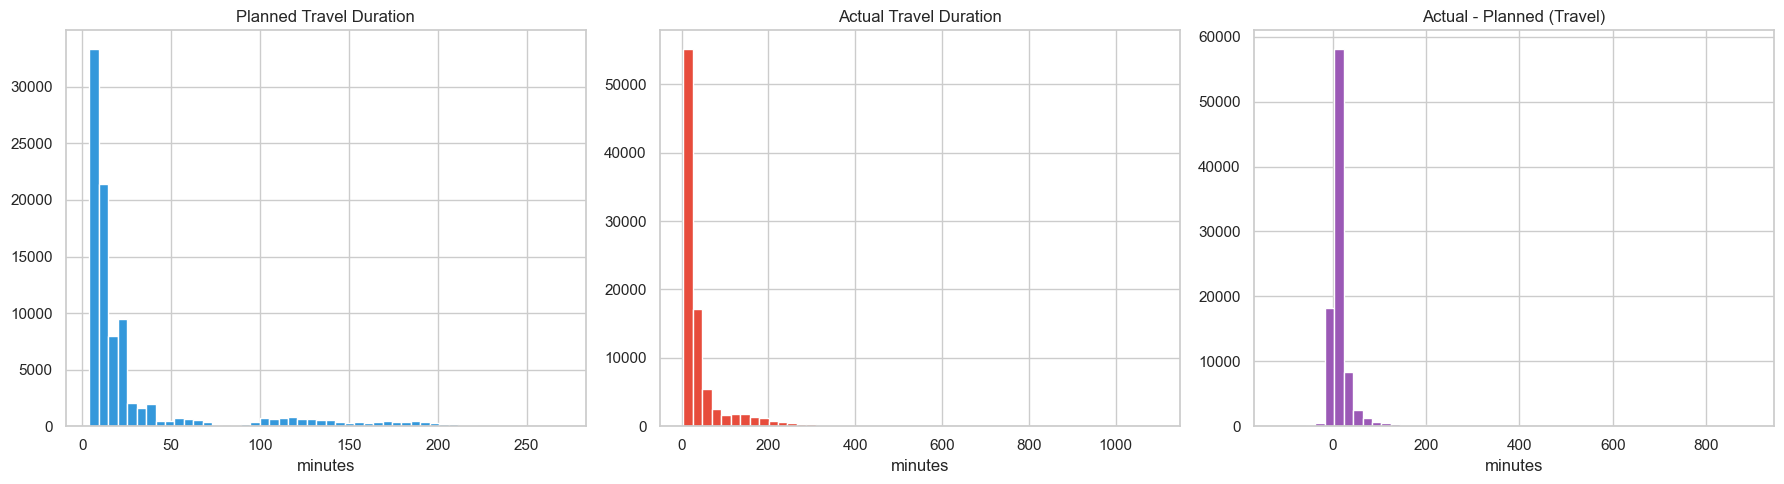

In [25]:
# Planned vs actual times — key for label construction
print('Planned travel duration stats:')
display(route_legs['planned_travel_duration_min'].describe())

print('\nActual travel duration stats:')
display(route_legs['actual_travel_duration_min'].describe())

# Difference between planned and actual
route_legs['travel_diff_min'] = route_legs['actual_travel_duration_min'] - route_legs['planned_travel_duration_min']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

route_legs['planned_travel_duration_min'].hist(bins=50, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Planned Travel Duration')
axes[0].set_xlabel('minutes')

route_legs['actual_travel_duration_min'].hist(bins=50, ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Actual Travel Duration')
axes[1].set_xlabel('minutes')

route_legs['travel_diff_min'].hist(bins=50, ax=axes[2], color='#9b59b6', edgecolor='white')
axes[2].set_title('Actual - Planned (Travel)')
axes[2].set_xlabel('minutes')

plt.tight_layout()
plt.show()

Service time (derived label) stats:


count    91894.000000
mean        19.879666
std         15.747345
min          2.000000
25%         11.000000
50%         16.000000
75%         23.000000
max        428.000000
Name: service_time_min, dtype: float64

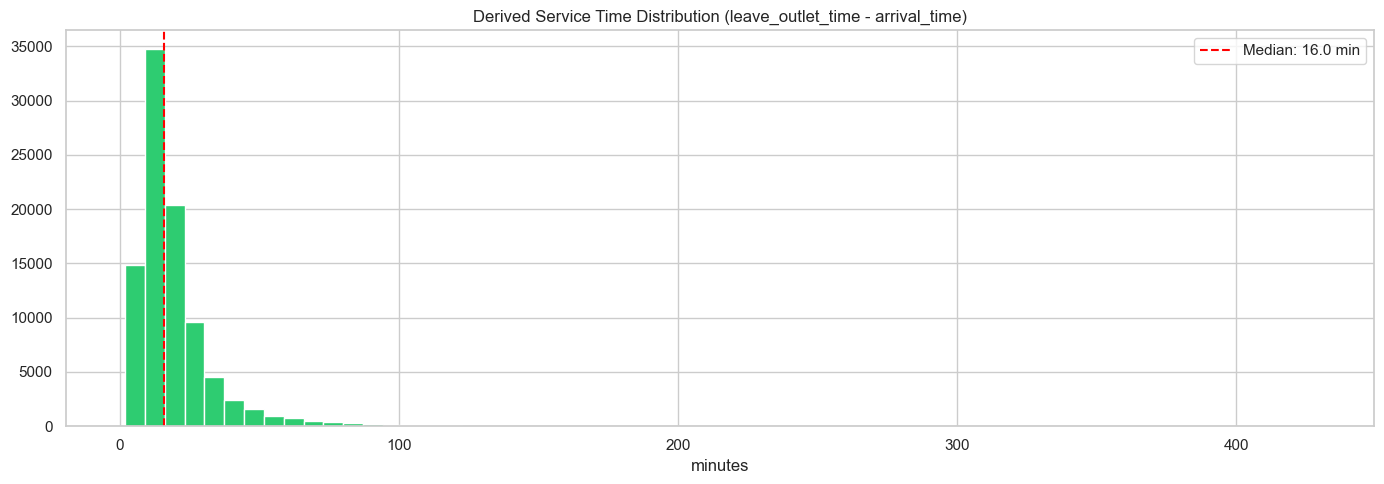

In [26]:
# Derive service time label: leave_outlet_time - arrival_time
def time_to_minutes(time_str):
    """Convert HH:MM to minutes from midnight."""
    if pd.isna(time_str):
        return np.nan
    parts = str(time_str).split(':')
    return int(parts[0]) * 60 + int(parts[1])

route_legs['arrival_min'] = route_legs['arrival_time'].apply(time_to_minutes)
route_legs['leave_min'] = route_legs['leave_outlet_time'].apply(time_to_minutes)

# Service time = leave - arrival (handle midnight if needed)
route_legs['service_time_min'] = route_legs['leave_min'] - route_legs['arrival_min']
# Fix midnight crossings (negative values)
route_legs.loc[route_legs['service_time_min'] < 0, 'service_time_min'] += 24 * 60

print('Service time (derived label) stats:')
display(route_legs['service_time_min'].describe())

fig, ax = plt.subplots(figsize=(14, 5))
route_legs['service_time_min'].hist(bins=60, ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title('Derived Service Time Distribution (leave_outlet_time - arrival_time)')
ax.set_xlabel('minutes')
ax.axvline(route_legs['service_time_min'].median(), color='red', linestyle='--', label=f'Median: {route_legs["service_time_min"].median():.1f} min')
ax.legend()
plt.tight_layout()
plt.show()

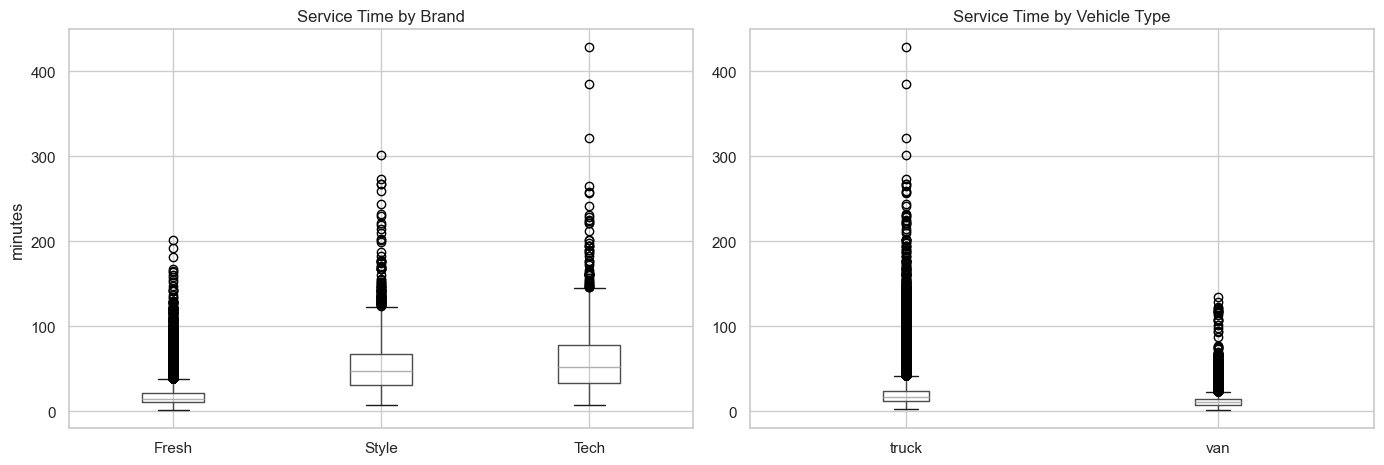

In [27]:
# Service time by brand and vehicle type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

route_legs.boxplot(column='service_time_min', by='brand', ax=axes[0])
axes[0].set_title('Service Time by Brand')
axes[0].set_xlabel('')
axes[0].set_ylabel('minutes')

route_legs.boxplot(column='service_time_min', by='vehicle_type', ax=axes[1])
axes[1].set_title('Service Time by Vehicle Type')
axes[1].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [28]:
# Derive late label: arrival_time > window_close_time
# Need to join route_legs with deliveries to get window times
dispatched = deliveries[deliveries['route_id'].notna()].copy()

merged = dispatched.merge(
    route_legs[['route_id', 'seq', 'arrival_time', 'leave_outlet_time', 'service_time_min']],
    left_on=['route_id', 'seq_in_route'],
    right_on=['route_id', 'seq'],
    how='inner'
)
print(f'Dispatched orders: {len(dispatched)}')
print(f'Successfully joined: {len(merged)}')
print(f'Join rate: {len(merged)/len(dispatched)*100:.1f}%')

# Compute lateness
merged['arrival_min'] = merged['arrival_time'].apply(time_to_minutes)
merged['window_close_min'] = merged['window_close_time'].apply(time_to_minutes)
merged['is_late'] = (merged['arrival_min'] > merged['window_close_min']).astype(int)

print(f'\nLate deliveries: {merged["is_late"].sum()} / {len(merged)} ({merged["is_late"].mean()*100:.1f}%)')
print(f'\nLate rate by brand:')
display(merged.groupby('brand')['is_late'].agg(['mean', 'sum', 'count']))

Dispatched orders: 91894
Successfully joined: 91894
Join rate: 100.0%

Late deliveries: 17991 / 91894 (19.6%)

Late rate by brand:


,mean,sum,count
brand,,,
Fresh,0.203517,17799,87457
Style,0.054885,150,2733
Tech,0.024648,42,1704


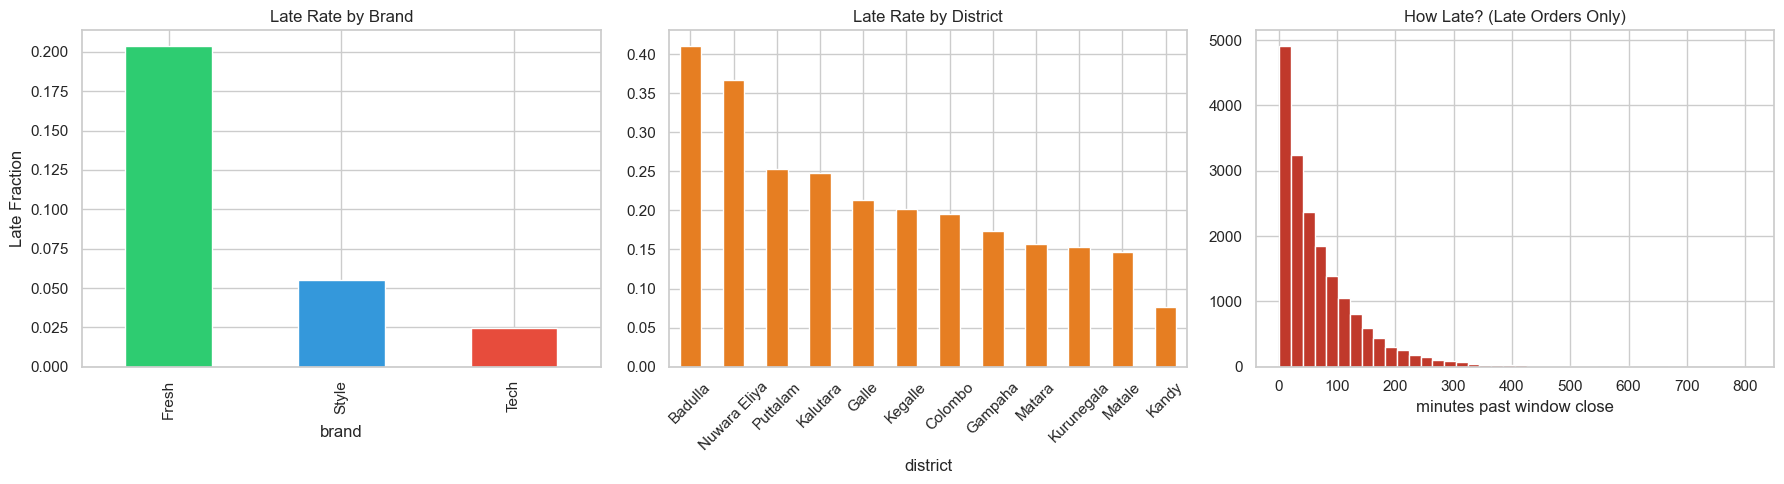

In [29]:
# Late delivery analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Late rate by brand
merged.groupby('brand')['is_late'].mean().plot.bar(ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Late Rate by Brand')
axes[0].set_ylabel('Late Fraction')

# Late rate by district
merged.groupby('district')['is_late'].mean().sort_values(ascending=False).plot.bar(ax=axes[1], color='#e67e22')
axes[1].set_title('Late Rate by District')
axes[1].tick_params(axis='x', rotation=45)

# Minutes late distribution (for late orders only)
late_orders = merged[merged['is_late'] == 1].copy()
late_orders['minutes_late'] = late_orders['arrival_min'] - late_orders['window_close_min']
late_orders['minutes_late'].hist(bins=40, ax=axes[2], color='#c0392b', edgecolor='white')
axes[2].set_title('How Late? (Late Orders Only)')
axes[2].set_xlabel('minutes past window close')

plt.tight_layout()
plt.show()

Stops per route:


count    25198.000000
mean         3.646877
std          2.044257
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         10.000000
dtype: float64

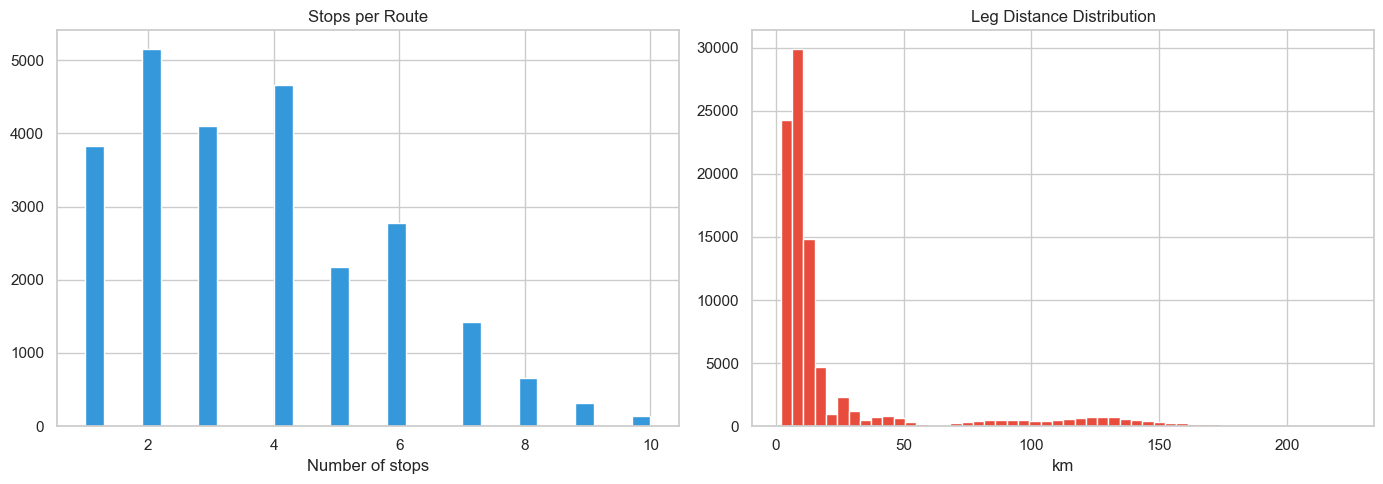

In [30]:
# Route characteristics
print('Stops per route:')
stops_per_route = route_legs.groupby('route_id').size()
display(stops_per_route.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stops_per_route.hist(bins=30, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Stops per Route')
axes[0].set_xlabel('Number of stops')

route_legs['distance_km'].hist(bins=50, ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Leg Distance Distribution')
axes[1].set_xlabel('km')

plt.tight_layout()
plt.show()

---
## 3. Test Data
### 3.1 Task 1 Test Inputs

In [31]:
task1_test = pd.read_csv(TEST / 'task1_test_inputs.csv')
print(f'Shape: {task1_test.shape}')
print(f'\nColumns: {list(task1_test.columns)}')
print(f'\nNull counts:\n{task1_test.isnull().sum()}')
print(f'\nDate range: {task1_test["order_date"].min()} to {task1_test["order_date"].max()}')
print(f'\nDispatch status: {task1_test["dispatch_status"].unique()}')
task1_test.head()

Shape: (5014, 20)

Columns: ['delivery_id', 'order_date', 'dispatch_date', 'dispatch_status', 'outlet_id', 'brand', 'district', 'depot', 'temp_requirement', 'order_units', 'order_weight_kg', 'order_volume_m3', 'route_id', 'seq_in_route', 'vehicle_id', 'vehicle_type', 'vehicle_temp', 'planned_arrival_time', 'window_open_time', 'window_close_time']

Null counts:
delivery_id             0
order_date              0
dispatch_date           0
dispatch_status         0
outlet_id               0
brand                   0
district                0
depot                   0
temp_requirement        0
order_units             0
order_weight_kg         0
order_volume_m3         0
route_id                0
seq_in_route            0
vehicle_id              0
vehicle_type            0
vehicle_temp            0
planned_arrival_time    0
window_open_time        0
window_close_time       0
dtype: int64

Date range: 2026-02-16 to 2026-03-28

Dispatch status: ['attempted' 'deferred']


,delivery_id,order_date,dispatch_date,dispatch_status,outlet_id,brand,district,depot,temp_requirement,order_units,order_weight_kg,order_volume_m3,route_id,seq_in_route,vehicle_id,vehicle_type,vehicle_temp,planned_arrival_time,window_open_time,window_close_time
0,ORD0092308,2026-02-16,2026-02-16,attempted,OUT001,Fresh,Colombo,Peliyagoda,ambient,11,92.1,0.501,R025229,0,VEH037,van,ambient,05:21,05:00,07:30
1,ORD0092309,2026-02-16,2026-02-16,attempted,OUT002,Fresh,Colombo,Peliyagoda,ambient,12,96.2,0.539,R025229,2,VEH037,van,ambient,06:10,05:30,08:00
2,ORD0092310,2026-02-16,2026-02-16,attempted,OUT003,Fresh,Colombo,Peliyagoda,ambient,13,89.8,0.472,R025229,1,VEH037,van,ambient,05:46,05:00,07:30
3,ORD0092311,2026-02-16,2026-02-16,attempted,OUT004,Fresh,Colombo,Peliyagoda,ambient,28,216.4,1.193,R025246,1,VEH021,truck,ambient,06:44,05:30,08:00
4,ORD0092312,2026-02-16,2026-02-16,attempted,OUT005,Fresh,Colombo,Peliyagoda,ambient,70,467.1,2.687,R025245,3,VEH012,truck,ambient,06:22,04:00,07:45


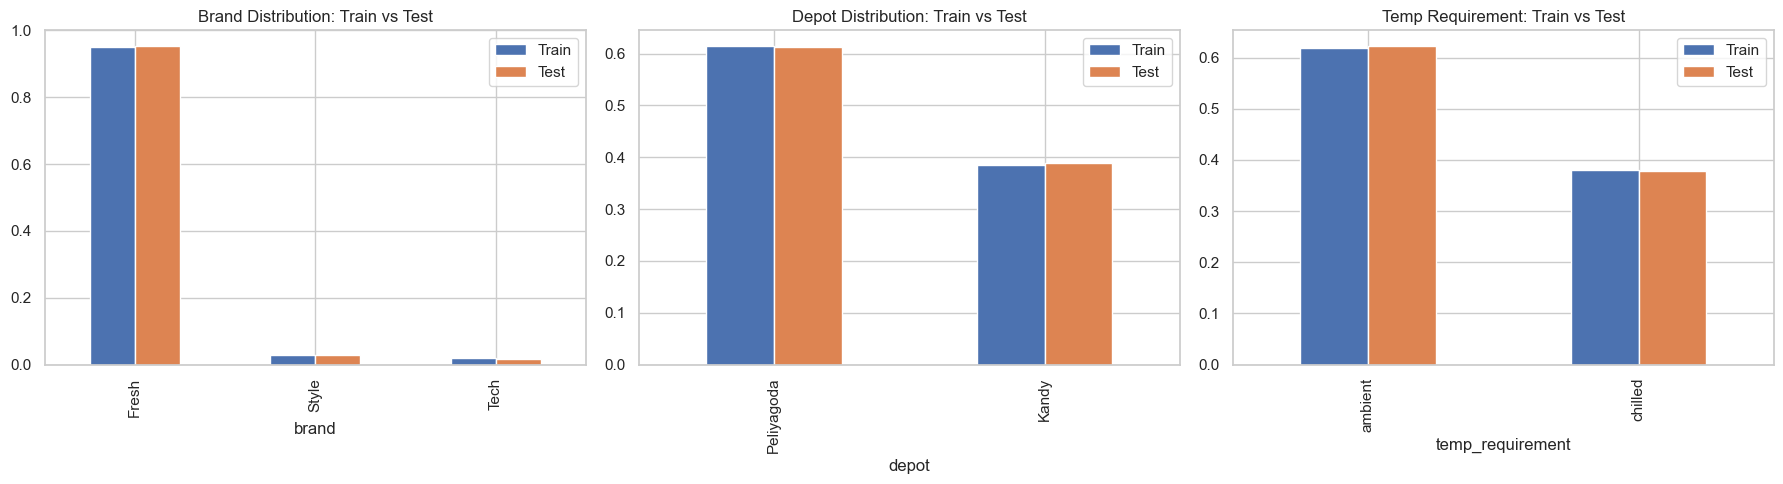

In [32]:
# Compare test vs train distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Brand distribution
train_brand = deliveries['brand'].value_counts(normalize=True)
test_brand = task1_test['brand'].value_counts(normalize=True)
pd.DataFrame({'Train': train_brand, 'Test': test_brand}).plot.bar(ax=axes[0])
axes[0].set_title('Brand Distribution: Train vs Test')

# Depot
train_depot = deliveries['depot'].value_counts(normalize=True)
test_depot = task1_test['depot'].value_counts(normalize=True)
pd.DataFrame({'Train': train_depot, 'Test': test_depot}).plot.bar(ax=axes[1])
axes[1].set_title('Depot Distribution: Train vs Test')

# Temp requirement
train_temp = deliveries['temp_requirement'].value_counts(normalize=True)
test_temp = task1_test['temp_requirement'].value_counts(normalize=True)
pd.DataFrame({'Train': train_temp, 'Test': test_temp}).plot.bar(ax=axes[2])
axes[2].set_title('Temp Requirement: Train vs Test')

plt.tight_layout()
plt.show()

In [33]:
# Route legs test
route_legs_test = pd.read_csv(TEST / 'route_legs_test.csv')
print(f'Shape: {route_legs_test.shape}')
print(f'\nColumns: {list(route_legs_test.columns)}')
print(f'\nNull counts:\n{route_legs_test.isnull().sum()}')
print('\n--- Note: actual_depart_time, actual_travel_duration_min, arrival_time, leave_outlet_time should be missing ---')
route_legs_test.head()

Shape: (5014, 18)

Columns: ['leg_id', 'date', 'route_id', 'depot', 'vehicle_id', 'vehicle_type', 'vehicle_temp', 'brand', 'district', 'seq', 'from_point', 'to_outlet', 'distance_km', 'planned_depart_time', 'planned_travel_duration_min', 'planned_arrival_time', 'monsoon', 'dow']

Null counts:
leg_id                         0
date                           0
route_id                       0
depot                          0
vehicle_id                     0
vehicle_type                   0
vehicle_temp                   0
brand                          0
district                       0
seq                            0
from_point                     0
to_outlet                      0
distance_km                    0
planned_depart_time            0
planned_travel_duration_min    0
planned_arrival_time           0
monsoon                        0
dow                            0
dtype: int64

--- Note: actual_depart_time, actual_travel_duration_min, arrival_time, leave_outlet_time should b

,leg_id,date,route_id,depot,vehicle_id,vehicle_type,vehicle_temp,brand,district,seq,from_point,to_outlet,distance_km,planned_depart_time,planned_travel_duration_min,planned_arrival_time,monsoon,dow
0,L0091915,2026-02-16,R025215,Kandy,VEH057,van,reefer,Fresh,Kandy,0,DEPOT,OUT077,7.9,05:00,16,05:16,0,0
1,L0091916,2026-02-16,R025215,Kandy,VEH057,van,reefer,Fresh,Kandy,1,OUT077,OUT079,2.8,05:32,6,05:38,0,0
2,L0091917,2026-02-16,R025215,Kandy,VEH057,van,reefer,Fresh,Kandy,2,OUT079,OUT078,3.3,05:54,7,06:01,0,0
3,L0091918,2026-02-16,R025215,Kandy,VEH057,van,reefer,Fresh,Kandy,3,OUT078,OUT082,3.9,06:17,8,06:25,0,0
4,L0091919,2026-02-16,R025216,Kandy,VEH041,truck,reefer,Fresh,Badulla,0,DEPOT,OUT110,111.6,04:15,159,06:54,0,0


### 3.2 Task 2A Test Inputs

In [34]:
task2a_test = pd.read_csv(TEST / 'task2a_test_inputs.csv')
print(f'Shape: {task2a_test.shape}')
print(f'\nColumns: {list(task2a_test.columns)}')
print(f'\nForecast weeks: iso_week {task2a_test["iso_week"].min()} to {task2a_test["iso_week"].max()}')
print(f'ISO years: {task2a_test["iso_year"].unique()}')
print(f'Depots: {task2a_test["depot"].unique()}')
print(f'Brands: {task2a_test["brand"].unique()}')
display(task2a_test)

Shape: (60, 5)

Columns: ['row_id', 'depot', 'brand', 'iso_year', 'iso_week']

Forecast weeks: iso_week 14 to 23
ISO years: [2026]
Depots: ['Kandy' 'Peliyagoda']
Brands: ['Fresh' 'Style' 'Tech']


,row_id,depot,brand,iso_year,iso_week
0,W0000,Kandy,Fresh,2026,14
1,W0001,Kandy,Style,2026,14
2,W0002,Kandy,Tech,2026,14
3,W0003,Peliyagoda,Fresh,2026,14
4,W0004,Peliyagoda,Style,2026,14
5,W0005,Peliyagoda,Tech,2026,14
6,W0006,Kandy,Fresh,2026,15
7,W0007,Kandy,Style,2026,15
8,W0008,Kandy,Tech,2026,15
9,W0009,Peliyagoda,Fresh,2026,15


### 3.3 Task 2B Scenario

In [35]:
task2b_orders = pd.read_csv(TEST / 'task2b_peak_day_scenarios.csv')
print(f'Shape: {task2b_orders.shape}')
print(f'\nColumns: {list(task2b_orders.columns)}')
display(task2b_orders.head())

print(f'\nOrders by brand:')
display(task2b_orders['brand'].value_counts())
print(f'\nOrders by district:')
display(task2b_orders['district'].value_counts())
print(f'\nTemp requirements:')
display(task2b_orders['temp_requirement'].value_counts())
print(f'\nParking constraints:')
display(task2b_orders['parking_constraint'].value_counts())
print(f'\nDeferred yesterday: {task2b_orders["deferred_yesterday"].sum()} orders')

Shape: (85, 17)

Columns: ['scenario', 'order_ref', 'outlet_id', 'brand', 'district', 'depot', 'dock_type', 'parking_constraint', 'mall_window', 'window_open_time', 'window_close_time', 'temp_requirement', 'order_units', 'order_weight_kg', 'order_volume_m3', 'deferred_yesterday', 'days_since_last_served']


,scenario,order_ref,outlet_id,brand,district,depot,dock_type,parking_constraint,mall_window,window_open_time,window_close_time,temp_requirement,order_units,order_weight_kg,order_volume_m3,deferred_yesterday,days_since_last_served
0,S1,S1-000,OUT001,Fresh,Colombo,Peliyagoda,street,van_only,NaN,05:00,07:30,ambient,12,97.8,0.500,0,1
1,S1,S1-001,OUT001,Fresh,Colombo,Peliyagoda,street,van_only,NaN,05:00,07:30,chilled,80,448.6,2.445,0,2
2,S1,S1-002,OUT002,Fresh,Colombo,Peliyagoda,street,van_only,NaN,05:30,08:00,ambient,18,130.9,0.666,0,2
3,S1,S1-003,OUT002,Fresh,Colombo,Peliyagoda,street,van_only,NaN,05:30,08:00,chilled,38,329.0,1.843,0,1
4,S1,S1-004,OUT003,Fresh,Colombo,Peliyagoda,street,van_only,NaN,05:00,07:30,ambient,28,160.6,0.870,0,1



Orders by brand:


brand
Fresh    75
Tech      5
Style     5
Name: count, dtype: int64


Orders by district:


...


Temp requirements:


temp_requirement
ambient    59
chilled    26
Name: count, dtype: int64


Parking constraints:


parking_constraint
normal       77
van_only      6
mall_dock     2
Name: count, dtype: int64


Deferred yesterday: 10 orders


In [36]:
# Task 2B fleet
task2b_fleet = pd.read_csv(TEST / 'task2b_peak_day_fleet.csv')
print(f'Shape: {task2b_fleet.shape}')
display(task2b_fleet['status'].value_counts())

# Available fleet details
available = task2b_fleet[task2b_fleet['status'] == 'available']
available_vehicles = available.merge(vehicles, on='vehicle_id', how='left')

print(f'\nAvailable vehicles: {len(available)}')
print(f'In workshop: {(task2b_fleet["status"] == "in_workshop").sum()}')
print(f'\nAvailable vehicle breakdown:')
display(pd.crosstab(available_vehicles['type'], available_vehicles['temp'], margins=True))
print(f'\nAvailable by depot:')
display(available_vehicles['depot'].value_counts())

Shape: (38, 3)


status
available      28
in_workshop    10
Name: count, dtype: int64


Available vehicles: 28
In workshop: 10

Available vehicle breakdown:


temp,ambient,reefer,All
type,,,
truck,22,3,25
van,2,1,3
All,24,4,28



Available by depot:


depot
Peliyagoda    28
Name: count, dtype: int64

In [37]:
# Task 2B demand vs capacity analysis
total_demand_vol = task2b_orders['order_volume_m3'].sum()
total_demand_wt = task2b_orders['order_weight_kg'].sum()

# Peliyagoda-only available vehicles (S1 is Peliyagoda)
peli_available = available_vehicles[available_vehicles['depot'] == 'Peliyagoda']
total_cap_vol = peli_available['volume_cap_m3'].sum() * 2  # max 2 trips
total_cap_wt = peli_available['weight_cap_kg'].sum() * 2

print(f'=== Task 2B Demand vs Capacity ===')
print(f'Total demand volume: {total_demand_vol:.1f} m³')
print(f'Total capacity volume (2 trips): {total_cap_vol:.1f} m³')
print(f'Volume utilization: {total_demand_vol/total_cap_vol*100:.1f}%')
print(f'\nTotal demand weight: {total_demand_wt:.1f} kg')
print(f'Total capacity weight (2 trips): {total_cap_wt:.1f} kg')
print(f'Weight utilization: {total_demand_wt/total_cap_wt*100:.1f}%')
print(f'\nChilled orders: {(task2b_orders["temp_requirement"]=="chilled").sum()}')
print(f'Available reefer vehicles (Peliyagoda): {(peli_available["temp"]=="reefer").sum()}')
print(f'Van-only orders: {(task2b_orders["parking_constraint"]=="van_only").sum()}')
print(f'Available vans (Peliyagoda): {(peli_available["type"]=="van").sum()}')

=== Task 2B Demand vs Capacity ===
Total demand volume: 409.9 m³
Total capacity volume (2 trips): 1518.4 m³
Volume utilization: 27.0%

Total demand weight: 68139.4 kg
Total capacity weight (2 trips): 281800.0 kg
Weight utilization: 24.2%

Chilled orders: 26
Available reefer vehicles (Peliyagoda): 4
Van-only orders: 6
Available vans (Peliyagoda): 3


---
## 4. Submission Templates

In [38]:
sub1 = pd.read_csv(TEMPLATES / 'submission_task1.csv')
sub2a = pd.read_csv(TEMPLATES / 'submission_task2a.csv')
sub2b = pd.read_csv(TEMPLATES / 'submission_task2b.csv')

print(f'Task 1 template: {sub1.shape} — columns: {list(sub1.columns)}')
display(sub1.head())

print(f'\nTask 2A template: {sub2a.shape} — columns: {list(sub2a.columns)}')
display(sub2a.head())

print(f'\nTask 2B template: {sub2b.shape} — columns: {list(sub2b.columns)}')
display(sub2b.head())

Task 1 template: (5014, 3) — columns: ['delivery_id', 'pred_service_min', 'pred_late_prob']


,delivery_id,pred_service_min,pred_late_prob
0,ORD0092308,NaN,NaN
1,ORD0092309,NaN,NaN
2,ORD0092310,NaN,NaN
3,ORD0092311,NaN,NaN
4,ORD0092312,NaN,NaN



Task 2A template: (60, 3) — columns: ['row_id', 'pred_total_volume_m3', 'pred_chilled_volume_m3']


,row_id,pred_total_volume_m3,pred_chilled_volume_m3
0,W0000,NaN,NaN
1,W0001,NaN,NaN
2,W0002,NaN,NaN
3,W0003,NaN,NaN
4,W0004,NaN,NaN



Task 2B template: (85, 6) — columns: ['scenario', 'order_ref', 'outlet_id', 'decision', 'vehicle_id', 'trip_id']


,scenario,order_ref,outlet_id,decision,vehicle_id,trip_id
0,S1,S1-000,OUT001,(served/deferred),(e.g. VEH014),(1 or 2)
1,S1,S1-001,OUT001,(served/deferred),(e.g. VEH014),(1 or 2)
2,S1,S1-002,OUT002,(served/deferred),(e.g. VEH014),(1 or 2)
3,S1,S1-003,OUT002,(served/deferred),(e.g. VEH014),(1 or 2)
4,S1,S1-004,OUT003,(served/deferred),(e.g. VEH014),(1 or 2)


---
## 5. Key Findings Summary

Run all cells above, then fill in observations here:

### Data Quality
- [ ] Any missing values in critical columns?
- [ ] Any unexpected values / outliers?
- [ ] Do joins work cleanly (deliveries <-> route_legs)?

### Label Construction
- [ ] Service time distribution — any negative or extreme values?
- [ ] Late rate — overall and by brand/district
- [ ] Any edge cases with time calculations?

### Task 2A
- [ ] Demand trends over time
- [ ] Festival / payday effects visible?
- [ ] Train vs test period gap?

### Task 2B
- [ ] What's the bottleneck? (volume, weight, reefer, vans, time?)
- [ ] How many orders must be deferred?
- [ ] Which brand/district is most constrained?